In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../data/Call-Center-Dataset.xlsx')
df.shape

(5000, 9)

In [3]:
df.head()

,Call Id,Date,Agent,Department,Answered (Y/N),Resolved,Speed of Answer,AvgTalkDuration,Satisfaction rating
0,ID0001,2015-01-01 09:12:58.000,Diane,Washing Machine,Y,Y,109.0,00:02:23.210000,3.0
1,ID0002,2015-01-01 09:12:57.600,Becky,Air Conditioner,Y,N,70.0,00:04:02.323000,3.0
2,ID0003,2015-01-01 09:47:31.200,Stewart,Washing Machine,Y,Y,10.0,00:02:11.202000,3.0
3,ID0004,2015-01-01 09:47:31.200,Greg,Washing Machine,Y,Y,53.0,00:00:37.481000,2.0
4,ID0005,2015-01-01 10:00:28.800,Becky,Toaster,Y,Y,95.0,00:01:00.083000,3.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Call Id              5000 non-null   str           
 1   Date                 5000 non-null   datetime64[us]
 2   Agent                5000 non-null   str           
 3   Department           5000 non-null   str           
 4   Answered (Y/N)       5000 non-null   str           
 5   Resolved             5000 non-null   str           
 6   Speed of Answer      4054 non-null   float64       
 7   AvgTalkDuration      4054 non-null   object        
 8   Satisfaction rating  4054 non-null   float64       
dtypes: datetime64[us](1), float64(2), object(1), str(5)
memory usage: 351.7+ KB


In [5]:
df[df['Answered (Y/N)']=='N'].shape[0]

946

In [6]:
df['Date'].min(),df['Date'].max()

(Timestamp('2015-01-01 09:12:57.600000'),
 Timestamp('2015-03-31 17:39:50.400000'))

In [7]:
df['date_only']=df['Date'].dt.date
df['hour']=df['Date'].dt.hour
df['day_of_week']=df['Date'].dt.day_name()
df['week_number']=df['Date'].dt.isocalendar().week

In [8]:
df[['Date','date_only','hour','day_of_week','week_number']].head()

,Date,date_only,hour,day_of_week,week_number
0,2015-01-01 09:12:58.000,2015-01-01,9,Thursday,1
1,2015-01-01 09:12:57.600,2015-01-01,9,Thursday,1
2,2015-01-01 09:47:31.200,2015-01-01,9,Thursday,1
3,2015-01-01 09:47:31.200,2015-01-01,9,Thursday,1
4,2015-01-01 10:00:28.800,2015-01-01,10,Thursday,1


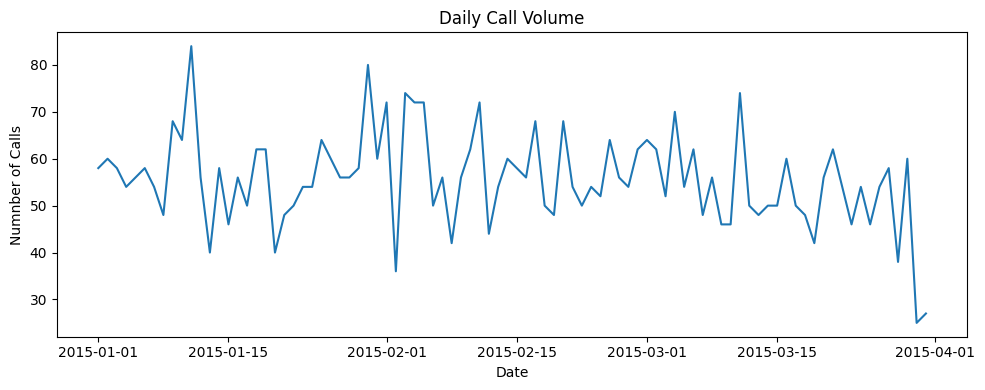

In [9]:
daily_volume= df.groupby('date_only').size()
daily_volume.plot(figsize=(10,4),title='Daily Call Volume')
plt.xlabel('Date')
plt.ylabel('Numnber of Calls')
plt.tight_layout()
plt.show()

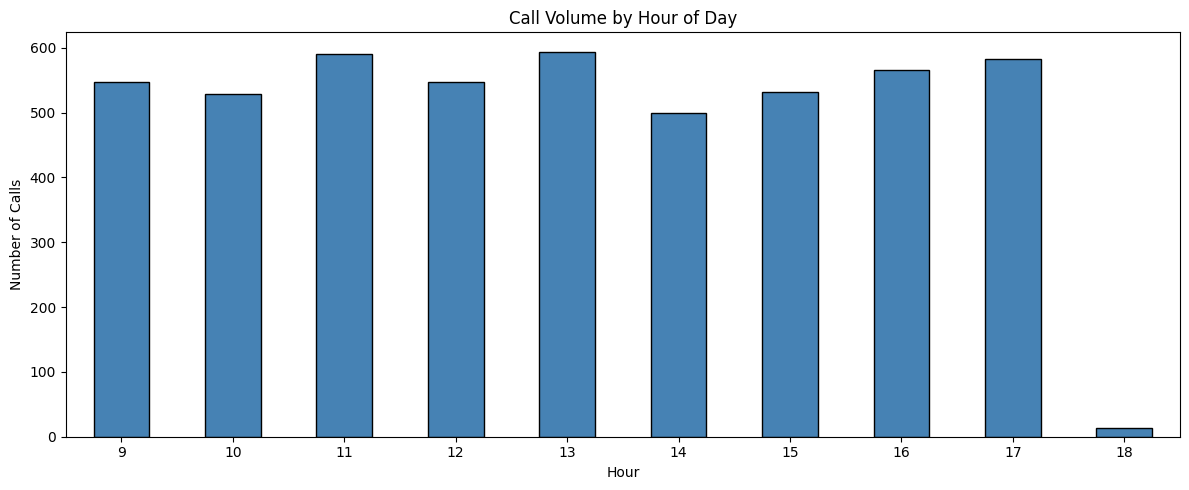

In [10]:
hourly_volume=df.groupby('hour').size()

plt.figure(figsize=(12,5))
hourly_volume.plot(kind='bar', color='steelblue',edgecolor='black')
plt.title('Call Volume by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Hourly Volume Insight
- Operating hours: 9:00 - 17:00 (hour 18 has negligible volume)
- Relatively flat distribution (~500-595 calls per hour)
- Slight peaks at 11:00 and 13:00
- Post-lunch dip at 14:00 (499 calls) — common in contact centers
- No extreme peaks = staffing requirements won't vary dramatically by hour

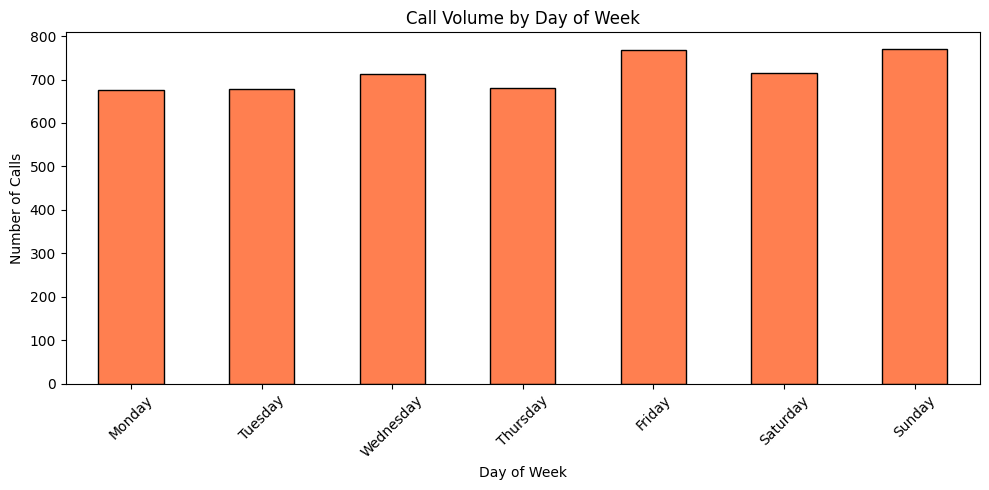

In [11]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_volume = df.groupby('day_of_week').size()
dow_volume = dow_volume.reindex(day_order)

plt.figure(figsize=(10, 5))
dow_volume.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Call Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Calls')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Day of Week Insight
- All 7 days active (this is a 7-day operation)
- Very flat distribution: 675 (Monday) to 770 (Sunday)
- Only 95-call spread across the week (~14% variation)
- No strong day-of-week effect — unlike typical contact centers where Monday is heaviest
- Limitation: this reduces the value of day-of-week as a forecast feature

In [18]:
# Convert AvgTalkDuration (time object) to seconds
df['AHT_seconds'] = df['AvgTalkDuration'].apply(
    lambda x: x.hour * 3600 + x.minute * 60 + x.second if pd.notna(x) else None
)

# Only look at answered calls
answered = df[df['Answered (Y/N)'] == 'Y']

print(f"Total answered calls: {len(answered)}")
print(f"\nAHT Summary (seconds):")
print(answered['AHT_seconds'].describe())

Total answered calls: 4054

AHT Summary (seconds):
count    4054.000000
mean      224.424026
std       111.371053
min        30.000000
25%       130.000000
50%       226.000000
75%       319.000000
max       419.000000
Name: AHT_seconds, dtype: float64


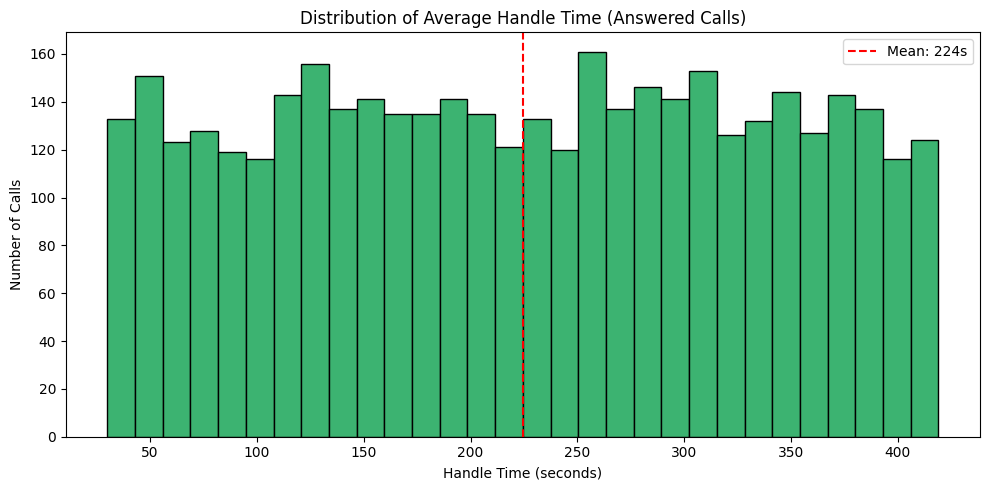

In [19]:
# AHT Distribution
plt.figure(figsize=(10, 5))
plt.hist(answered['AHT_seconds'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Average Handle Time (Answered Calls)')
plt.xlabel('Handle Time (seconds)')
plt.ylabel('Number of Calls')
plt.axvline(answered['AHT_seconds'].mean(), color='red', linestyle='--', label=f"Mean: {answered['AHT_seconds'].mean():.0f}s")
plt.legend()
plt.tight_layout()
plt.show()

### AHT Analysis
- Mean AHT: 224 seconds (~3.7 minutes), Median: 226 seconds
- Symmetric, roughly uniform distribution (30s to 419s)
- No extreme outliers, no need for outlier removal
- Standard deviation: 111 seconds (wide spread is normal for multi-department centers)
- Note: Uniform AHT distribution is unusual for real call centers (typically right-skewed with a long tail). This is a dataset limitation worth acknowledging.

In [20]:
# AHT by Department
dept_aht = answered.groupby('Department')['AHT_seconds'].agg(['mean', 'median', 'count'])
dept_aht['mean'] = dept_aht['mean'].round(0)
dept_aht['median'] = dept_aht['median'].round(0)
print(dept_aht)

                  mean  median  count
Department                           
Air Conditioner  225.0   229.0    805
Fridge           228.0   234.0    795
Television       227.0   231.0    847
Toaster          215.0   208.0    818
Washing Machine  227.0   229.0    789


### AHT by Department
- All departments within 13 seconds of each other (215s - 228s)
- No meaningful variation — a single AHT value (~224s) is sufficient for staffing
- Call volumes also evenly distributed across departments (~790-850 each)
- Limitation: Real contact centers typically show significant AHT differences by queue/skill group

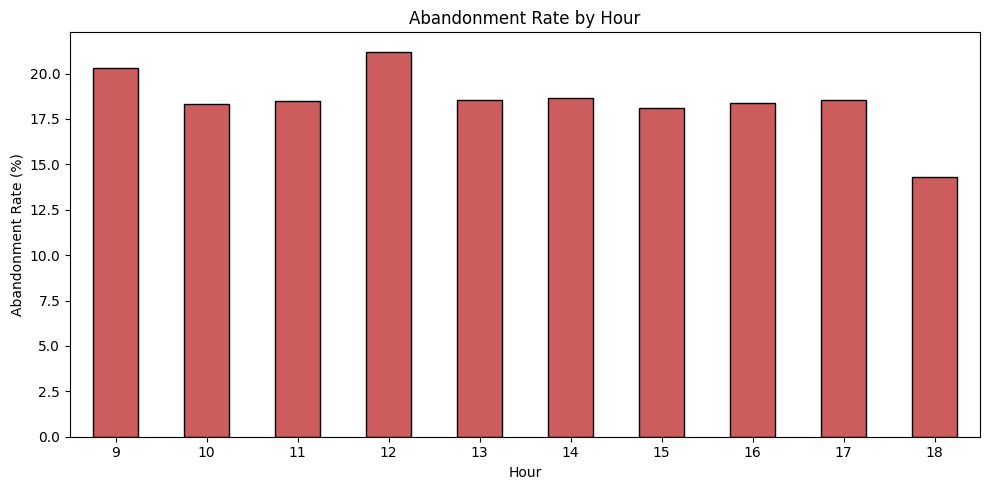

hour
9     20.3
10    18.3
11    18.5
12    21.2
13    18.5
14    18.6
15    18.1
16    18.4
17    18.5
18    14.3
dtype: float64


In [27]:
abandon_by_hour = df.groupby('hour').apply(
    lambda x: (x['Answered (Y/N)'] == 'N').sum() / len(x) * 100
)


plt.figure(figsize=(10, 5))
abandon_by_hour.plot(kind='bar', color='indianred', edgecolor='black')
plt.title('Abandonment Rate by Hour')
plt.xlabel('Hour')
plt.ylabel('Abandonment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(abandon_by_hour.round(1))

### Abandonment Rate Analysis
- Overall abandonment: ~18-21% across all hours (946 out of 5000 calls)
- No significant hourly variation consistently high
- Industry benchmark is 3-5%  this center is severely understaffed
- Hour 12 worst (21.2%), but the difference is marginal
- Flat abandonment pattern suggests uniform understaffing, not interval-specific gaps
- This will be a key input for Erlang C: calculate how many agents are needed to bring abandonment below 5%

         total_calls  avg_aht
Agent                        
Jim              536    228.0
Dan              523    231.0
Becky            517    220.0
Martha           514    223.0
Greg             502    226.0
Diane            501    218.0
Joe              484    224.0
Stewart          477    226.0


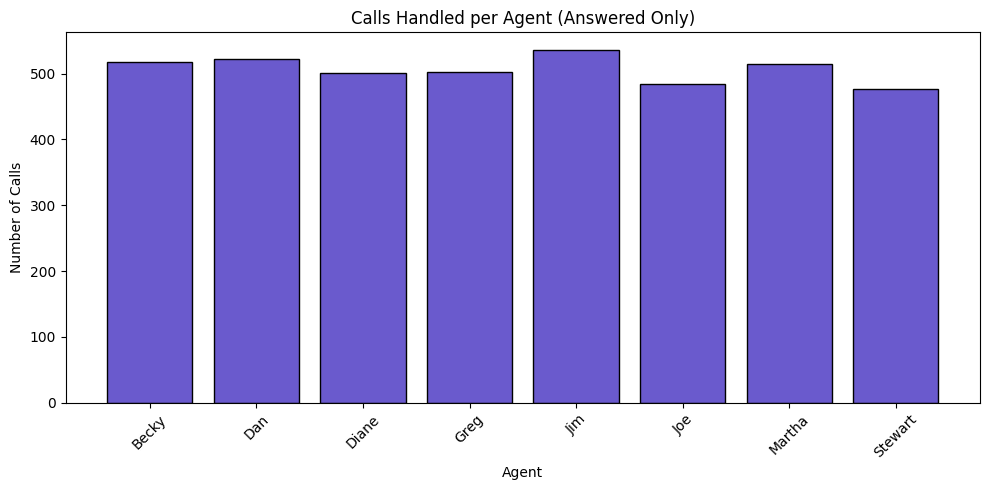

In [28]:
# Agent Workload Distribution
agent_stats = answered.groupby('Agent').agg(
    total_calls=('Call Id', 'count'),
    avg_aht=('AHT_seconds', 'mean')
).round(0)

print(agent_stats.sort_values('total_calls', ascending=False))

plt.figure(figsize=(10, 5))
plt.bar(agent_stats.index, agent_stats['total_calls'], color='slateblue', edgecolor='black')
plt.title('Calls Handled per Agent (Answered Only)')
plt.xlabel('Agent')
plt.ylabel('Number of Calls')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Agent Workload Distribution
- 8 agents, range: 477 (Stewart) to 536 (Jim) answered calls
- ~12% spread, relatively balanced workload
- AHT per agent: 218s - 231s, no significant performance variation
- Agents are functionally interchangeable in this dataset
- Supports using a single pooled staffing model (no need for agent-specific modeling)

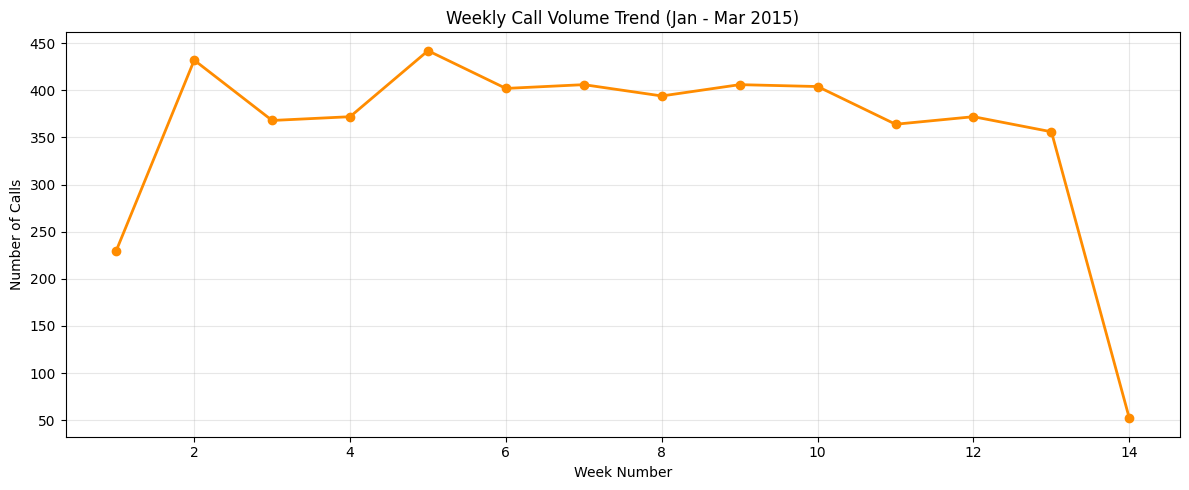

week_number
1     230
2     432
3     368
4     372
5     442
6     402
7     406
8     394
9     406
10    404
11    364
12    372
13    356
14     52
dtype: int64


In [29]:
# Week over Week Call Volume Trend
weekly_volume = df.groupby('week_number').size()

plt.figure(figsize=(12, 5))
weekly_volume.plot(kind='line', marker='o', color='darkorange', linewidth=2)
plt.title('Weekly Call Volume Trend (Jan - Mar 2015)')
plt.xlabel('Week Number')
plt.ylabel('Number of Calls')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(weekly_volume)

### Week over Week Trend
- Weeks 1 and 14 are partial weeks (data starts/ends mid-week) — excluded from analysis
- Weeks 2-13: range 356 to 442 calls per week
- No clear upward or downward trend — volume is stationary
- Stationary data is good news for forecasting: simpler models (no trend component needed)
- Limitation: 3 months is too short to detect seasonal patterns (e.g., summer vs winter)
```

All 6 analyses done:
1. Hourly volume profile — flat
2. Day of week profile — flat
3. AHT analysis — uniform ~224 seconds
4. Abandonment rate — consistently high ~18-20%
5. Agent workload — evenly distributed
6. Week over week trend — stationary

